# Set 11 - Anomalieerkennung und die schwierige Threshold-Wahl

Anomalieverfahren liefern meist zuerst nur einen Score. Erst ein Threshold macht daraus die Entscheidung normal oder anomal.

Dieses Notebook zeigt:

- fünf unterschiedliche Anomalie-Scores
- Quantil-, label- und kostenbasierte Thresholds
- den Zielkonflikt zwischen False Positives und False Negatives
- warum eine Schwelle bei veränderter Datenverteilung versagen kann

Die synthetisch bekannten Labels werden nie zum Fit der Detektoren verwendet. Sie dienen nur zur nachträglichen Bewertung und zur bewusst überwachten Kalibrierung einzelner Schwellen.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from ipywidgets import FloatSlider, interact
from sklearn.cluster import KMeans
from sklearn.ensemble import IsolationForest
from sklearn.metrics import (
    average_precision_score,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.mixture import GaussianMixture
from sklearn.neighbors import LocalOutlierFactor
from sklearn.preprocessing import StandardScaler
from sklearn.svm import OneClassSVM

RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)
plt.style.use("seaborn-v0_8-whitegrid")


## 1. Normale Struktur und zwei Arten von Anomalien

Normale Daten bilden zwei elliptische Betriebszustände. Offensichtliche Anomalien liegen weit außerhalb; schwierige Anomalien liegen zwischen den Zuständen oder überlappen deren Randbereiche.


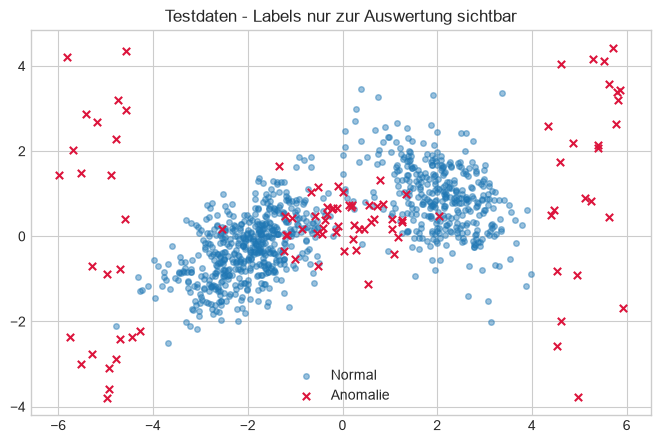

In [2]:
def sample_normal(n, shift=(0.0, 0.0), scale=1.0):
    components = rng.choice(2, size=n, p=[0.58, 0.42])
    means = np.array([[-2.0, -0.3], [2.1, 0.9]]) + np.asarray(shift)
    covariances = np.array([
        [[0.75, 0.35], [0.35, 0.55]],
        [[0.60, -0.28], [-0.28, 0.75]],
    ]) * scale**2
    return np.vstack([
        rng.multivariate_normal(means[c], covariances[c])
        for c in components
    ])

def sample_anomalies(n):
    n_easy = n // 2
    easy_left = rng.uniform([-6.0, -4.5], [-4.2, 4.5], size=(n_easy//2, 2))
    easy_right = rng.uniform([4.3, -4.5], [6.0, 4.5], size=(n_easy-n_easy//2, 2))
    difficult = rng.multivariate_normal(
        mean=[0.0, 0.35],
        cov=[[0.8, 0.0], [0.0, 0.32]],
        size=n-n_easy,
    )
    return np.vstack([easy_left, easy_right, difficult])

# Der Fit-Pool enthält wenige unbekannte Anomalien, aber keine verwendeten Labels.
X_train = np.vstack([sample_normal(1400), sample_anomalies(18)])
hidden_train_labels = np.r_[np.zeros(1400, dtype=int), np.ones(18, dtype=int)]

X_calibration = np.vstack([sample_normal(520), sample_anomalies(65)])
y_calibration = np.r_[np.zeros(520, dtype=int), np.ones(65, dtype=int)]

X_test = np.vstack([sample_normal(900), sample_anomalies(100)])
y_test = np.r_[np.zeros(900, dtype=int), np.ones(100, dtype=int)]

train_order = rng.permutation(len(X_train))
calibration_order = rng.permutation(len(X_calibration))
test_order = rng.permutation(len(X_test))
X_train, hidden_train_labels = X_train[train_order], hidden_train_labels[train_order]
X_calibration, y_calibration = X_calibration[calibration_order], y_calibration[calibration_order]
X_test, y_test = X_test[test_order], y_test[test_order]

plt.figure(figsize=(8, 5))
plt.scatter(X_test[y_test == 0, 0], X_test[y_test == 0, 1],
            s=16, alpha=0.45, label="Normal")
plt.scatter(X_test[y_test == 1, 0], X_test[y_test == 1, 1],
            s=28, color="crimson", marker="x", label="Anomalie")
plt.title("Testdaten - Labels nur zur Auswertung sichtbar")
plt.legend(); plt.show()


## 2. Verschiedene Modelle, verschiedene Scores

Wir drehen alle Scores so, dass größere Werte immer ungewöhnlicher bedeuten. Absolute Zahlen verschiedener Verfahren sind nicht direkt vergleichbar.


In [3]:
scaler = StandardScaler().fit(X_train)
train_scaled = scaler.transform(X_train)
calibration_scaled = scaler.transform(X_calibration)
test_scaled = scaler.transform(X_test)

kmeans = KMeans(n_clusters=2, n_init=20, random_state=RANDOM_STATE).fit(train_scaled)
gmm = GaussianMixture(
    n_components=2, covariance_type="full",
    n_init=5, random_state=RANDOM_STATE
).fit(train_scaled)
isolation = IsolationForest(
    n_estimators=300, contamination="auto",
    random_state=RANDOM_STATE
).fit(train_scaled)
lof = LocalOutlierFactor(
    n_neighbors=35, novelty=True, contamination="auto"
).fit(train_scaled)
one_class = OneClassSVM(nu=0.03, gamma="scale").fit(train_scaled)

score_functions = {
    "K-Means-Distanz": lambda data: np.min(kmeans.transform(data), axis=1),
    "GMM negative Log-Dichte": lambda data: -gmm.score_samples(data),
    "Isolation Forest": lambda data: -isolation.score_samples(data),
    "Local Outlier Factor": lambda data: -lof.score_samples(data),
    "One-Class SVM": lambda data: -one_class.score_samples(data),
}

comparison = []
for name, score_function in score_functions.items():
    scores = score_function(test_scaled)
    comparison.append({
        "Verfahren": name,
        "ROC-AUC": roc_auc_score(y_test, scores),
        "Average Precision": average_precision_score(y_test, scores),
    })
display(pd.DataFrame(comparison).sort_values("Average Precision", ascending=False).round(3))


,Verfahren,ROC-AUC,Average Precision
4,One-Class SVM,0.945,0.754
1,GMM negative Log-Dichte,0.892,0.694
3,Local Outlier Factor,0.880,0.646
2,Isolation Forest,0.813,0.573
0,K-Means-Distanz,0.805,0.524


ROC-AUC und Average Precision verwenden hier die versteckten Labels und dienen nur zur didaktischen Bewertung. In einem wirklich ungelabelten Projekt stehen diese Kennzahlen nicht zur Verfügung.


## 3. Derselbe Score, viele mögliche Thresholds

Für die Detailanalyse verwenden wir den Isolation Forest. Eine rein unüberwachte Regel markiert beispielsweise die größten 1 Prozent der Trainingsscores. Ändert sich das Quantil, ändern sich False Positives und False Negatives deutlich.


In [4]:
train_scores = score_functions["Isolation Forest"](train_scaled)
calibration_scores = score_functions["Isolation Forest"](calibration_scaled)
test_scores = score_functions["Isolation Forest"](test_scaled)

def evaluate_threshold(scores, labels, threshold):
    predicted = (scores > threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(labels, predicted, labels=[0, 1]).ravel()
    return {
        "Markiert": predicted.mean(),
        "Precision": precision_score(labels, predicted, zero_division=0),
        "Recall": recall_score(labels, predicted, zero_division=0),
        "F1": f1_score(labels, predicted, zero_division=0),
        "False-Positive-Rate": fp/(fp+tn),
        "False Negatives": fn,
    }

rows = []
for quantile in [0.90, 0.95, 0.975, 0.99, 0.995]:
    threshold = np.quantile(train_scores, quantile)
    metrics = evaluate_threshold(test_scores, y_test, threshold)
    rows.append({"Trainingsquantil": quantile, "Threshold": threshold, **metrics})

threshold_table = pd.DataFrame(rows)
display(threshold_table.round(3))


,Trainingsquantil,Threshold,Markiert,Precision,Recall,F1,False-Positive-Rate,False Negatives
0,0.900,0.540,0.128,0.406,0.52,0.456,0.084,48
1,0.950,0.577,0.086,0.581,0.50,0.538,0.040,50
2,0.975,0.617,0.059,0.763,0.45,0.566,0.016,55
3,0.990,0.662,0.046,0.848,0.39,0.534,0.008,61
4,0.995,0.687,0.036,0.917,0.33,0.485,0.003,67


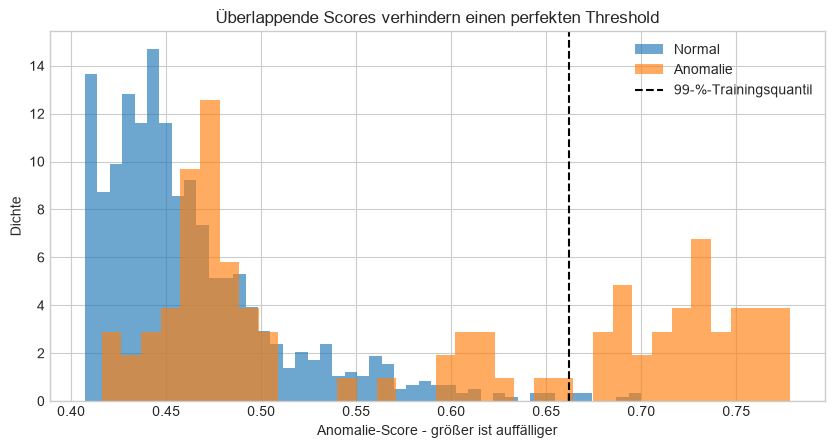

In [5]:
threshold_99 = np.quantile(train_scores, 0.99)
plt.figure(figsize=(10, 4.8))
plt.hist(test_scores[y_test == 0], bins=45, alpha=0.65, density=True, label="Normal")
plt.hist(test_scores[y_test == 1], bins=35, alpha=0.65, density=True, label="Anomalie")
plt.axvline(threshold_99, color="black", linestyle="--", label="99-%-Trainingsquantil")
plt.xlabel("Anomalie-Score - größer ist auffälliger")
plt.ylabel("Dichte")
plt.title("Überlappende Scores verhindern einen perfekten Threshold")
plt.legend(); plt.show()


## 4. Interaktiv: Schwelle verschieben

Der Slider verändert nur die Entscheidungsschwelle, nicht das bereits trainierte Modell. Beobachte, wie mehr Recall fast immer mit mehr Fehlalarmen bezahlt wird.


In [6]:
def show_threshold(percentile=99.0):
    threshold = np.percentile(train_scores, percentile)
    metrics = evaluate_threshold(test_scores, y_test, threshold)
    predicted = test_scores > threshold

    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
    axes[0].hist(test_scores[y_test == 0], bins=40, alpha=0.6, label="Normal")
    axes[0].hist(test_scores[y_test == 1], bins=30, alpha=0.6, label="Anomalie")
    axes[0].axvline(threshold, color="black", linestyle="--")
    axes[0].set_title(f"Threshold beim {percentile:.1f}. Perzentil")
    axes[0].legend()

    axes[1].scatter(
        X_test[~predicted, 0], X_test[~predicted, 1],
        s=14, alpha=0.35, label="Nicht markiert"
    )
    axes[1].scatter(
        X_test[predicted, 0], X_test[predicted, 1],
        s=30, color="crimson", marker="x", label="Markiert"
    )
    axes[1].set_title(
        f"Precision={metrics['Precision']:.2f}, Recall={metrics['Recall']:.2f}"
    )
    axes[1].legend()
    plt.tight_layout(); plt.show()

interact(
    show_threshold,
    percentile=FloatSlider(
        value=99.0, min=90.0, max=99.8, step=0.2,
        description="Perzentil"
    ),
)


interactive(children=(FloatSlider(value=99.0, description='Perzentil', max=99.8, min=90.0, step=0.2), Output()…

<function __main__.show_threshold(percentile=99.0)>

## 5. Labels können den Threshold kalibrieren - dann ist dieser Schritt überwacht

Der Detektor bleibt unüberwacht trainiert. Für die Schwelle nutzen wir nun jedoch gelabelte Kalibrierungsdaten und maximieren dort F1. Diese Wahl kann sinnvoll sein, ist aber nicht mehr rein unüberwacht.


In [7]:
precision, recall, thresholds = precision_recall_curve(
    y_calibration, calibration_scores
)
f1_values = 2*precision[:-1]*recall[:-1] / (
    precision[:-1] + recall[:-1] + 1e-12
)
best_index = int(np.argmax(f1_values))
supervised_threshold = thresholds[best_index]

print("Kalibrierter Threshold:", round(supervised_threshold, 3))
print("Bestes Kalibrierungs-F1:", round(f1_values[best_index], 3))
display(pd.DataFrame([
    {"Regel": "99-%-Quantil, ungelabelt",
     **evaluate_threshold(test_scores, y_test, threshold_99)},
    {"Regel": "F1 auf Kalibrierungslabels",
     **evaluate_threshold(test_scores, y_test, supervised_threshold)},
]).round(3))


Kalibrierter Threshold: 0.608
Bestes Kalibrierungs-F1: 0.577


,Regel,Markiert,Precision,Recall,F1,False-Positive-Rate,False Negatives
0,"99-%-Quantil, ungelabelt",0.046,0.848,0.39,0.534,0.008,61
1,F1 auf Kalibrierungslabels,0.063,0.730,0.46,0.564,0.019,54


## 6. Kosten bestimmen eine andere optimale Schwelle

Wenn eine übersehene Anomalie sehr teuer ist, wird die Schwelle niedriger. Wenn jeder Fehlalarm eine aufwendige Prüfung auslöst, wird sie höher. Ohne Kostenmodell gibt es kein allgemein optimales F1, Precision oder Recall.


In [8]:
candidate_thresholds = np.quantile(
    calibration_scores, np.linspace(0.50, 0.999, 500)
)
cost_scenarios = [
    ("Anomalie übersehen ist teuer", 1, 20),
    ("Fehlalarm ist teuer", 10, 1),
]
cost_rows = []

for scenario, false_positive_cost, false_negative_cost in cost_scenarios:
    total_costs = []
    for threshold in candidate_thresholds:
        predicted = calibration_scores > threshold
        tn, fp, fn, tp = confusion_matrix(
            y_calibration, predicted, labels=[0, 1]
        ).ravel()
        total_costs.append(
            fp*false_positive_cost + fn*false_negative_cost
        )
    best = int(np.argmin(total_costs))
    threshold = candidate_thresholds[best]
    cost_rows.append({
        "Szenario": scenario,
        "FP-Kosten": false_positive_cost,
        "FN-Kosten": false_negative_cost,
        "Threshold": threshold,
        "Kalibrierungskosten": total_costs[best],
        **evaluate_threshold(test_scores, y_test, threshold),
    })

display(pd.DataFrame(cost_rows).round(3))


,Szenario,FP-Kosten,FN-Kosten,Threshold,Kalibrierungskosten,Markiert,Precision,Recall,F1,False-Positive-Rate,False Negatives
0,Anomalie übersehen ist teuer,1,20,0.455,436,0.482,0.185,0.89,0.306,0.437,11
1,Fehlalarm ist teuer,10,1,0.692,49,0.033,0.939,0.31,0.466,0.002,69


## 7. Distribution Shift erzeugt plötzlich Fehlalarme

Der 99-Prozent-Threshold wurde aus der ursprünglichen Trainingsverteilung abgeleitet. Schon eine moderate Verschiebung und größere Streuung normaler Produktionsdaten kann die Fehlalarmrate deutlich verändern.


In [9]:
X_shifted_normal = sample_normal(
    1200, shift=(0.35, 0.20), scale=1.15
)
shifted_scores = score_functions["Isolation Forest"](
    scaler.transform(X_shifted_normal)
)

baseline_false_alarm = np.mean(
    score_functions["Isolation Forest"](
        scaler.transform(sample_normal(1200))
    ) > threshold_99
)
shifted_false_alarm = np.mean(shifted_scores > threshold_99)

print("Fehlalarmrate bei vergleichbarer Normalverteilung:",
      round(baseline_false_alarm, 3))
print("Fehlalarmrate nach Distribution Shift:",
      round(shifted_false_alarm, 3))


Fehlalarmrate bei vergleichbarer Normalverteilung: 0.002
Fehlalarmrate nach Distribution Shift: 0.014


## Fazit

- Ein Anomalie-Score ist eine Rangfolge, noch keine Entscheidung.
- Ein Quantil setzt implizit eine erwartete Anomalierate voraus.
- Gelabelte Kalibrierung macht die Threshold-Wahl überwacht, auch wenn das Score-Modell unüberwacht bleibt.
- Kosten und verfügbare Prüfkapazität bestimmen den sinnvollen Arbeitspunkt.
- Überlappende Score-Verteilungen verhindern perfekte Trennung.
- Bei Distribution Shift muss nicht nur das Modell, sondern auch die Schwelle überwacht und neu bewertet werden.
